# 🏒 NHL Game Statistics EDA (Final Polished Submission)

## Section 1: Introduction

This project analyzes an NHL game-level dataset containing team performance metrics such as goals, shots, hits, penalties, and power play opportunities for both home and away teams. Each row represents a team’s performance in a specific game.

The purpose of this project is to explore how different performance metrics relate to scoring and winning outcomes using descriptive statistics, visualizations, and regression analysis.

Key questions:
- Do teams that take more shots score more goals?
- Do home teams have an advantage?
- How do special teams (power plays) affect scoring?


## Section 2: Load and Inspect the Data

In [13]:
# Import libraries (only allowed ones)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('game_stats_v2.csv')

# Preview and inspect
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23735 entries, 0 to 23734
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   game_id                      23735 non-null  int64  
 1   date_time_GMT                23735 non-null  object 
 2   home_team                    23730 non-null  object 
 3   away_team                    23730 non-null  object 
 4   home_won                     23735 non-null  bool   
 5   home_settled_in              23735 non-null  object 
 6   home_head_coach              23721 non-null  object 
 7   home_goals                   23731 non-null  float64
 8   home_shots                   23731 non-null  float64
 9   home_hits                    21271 non-null  float64
 10  home_pim                     23731 non-null  float64
 11  home_powerPlayOpportunities  23731 non-null  float64
 12  home_powerPlayGoals          23731 non-null  float64
 13  home_faceOffWinP

,0
game_id,0
date_time_GMT,0
home_team,5
away_team,5
home_won,0
home_settled_in,0
home_head_coach,14
home_goals,4
home_shots,4
home_hits,2464


## Section 3: Data Cleaning and Preparation
Handle types and missing values.

In [14]:
# Convert date to datetime
df['date_time_GMT'] = pd.to_datetime(df['date_time_GMT'])

# Fill missing hits with mean
df['home_hits'] = df['home_hits'].fillna(df['home_hits'].mean())

# Convert percentage to numeric
df['home_faceOffWinPercentage'] = pd.to_numeric(df['home_faceOffWinPercentage'], errors='coerce')

## Section 4: Descriptive Statistics

These summaries show central tendency and spread for numerical variables, and frequency for categorical outcomes, helping understand typical performance and variability.


In [15]:
# Numerical stats
df.describe()

# Categorical counts
df['home_settled_in'].value_counts()

,count
home_settled_in,
REG,18153
OT,5563
tbc,19


## Helper Function (Code Reuse)

In [16]:
# Reusable histogram function
def plot_hist(series, title, xlabel):
    series.hist()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.show()

## Section 5: Numerical Data Visualizations

Histograms show distribution; boxplots reveal spread and outliers.


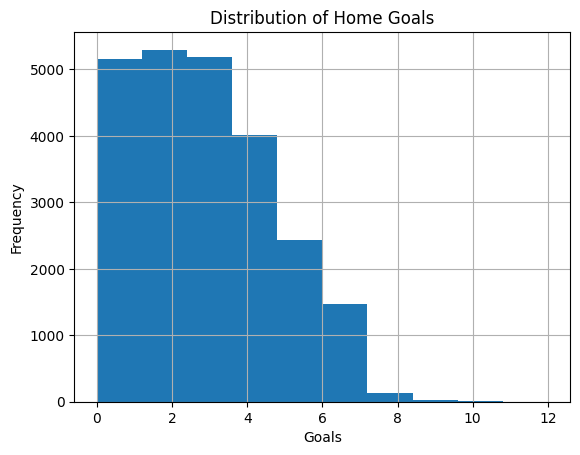

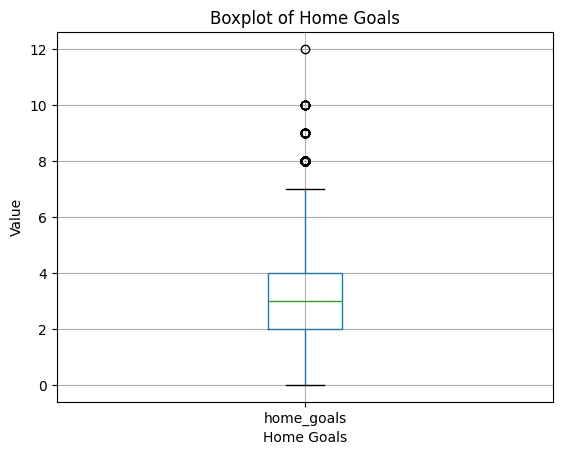

In [17]:
# Histogram
plot_hist(df['home_goals'], 'Distribution of Home Goals', 'Goals')

# Boxplot
df.boxplot(column='home_goals')
plt.title('Boxplot of Home Goals')
plt.xlabel('Home Goals')
plt.ylabel('Value')
plt.show()

## Section 6: Categorical Data Analysis

Bar and pie charts show how games are distributed across outcomes.


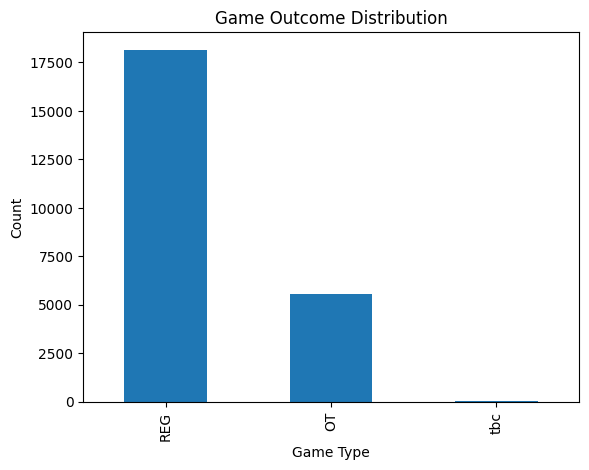

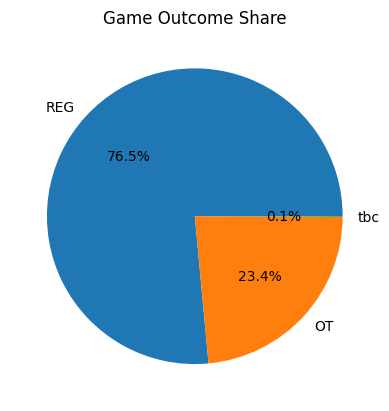

In [18]:
# Bar chart
df['home_settled_in'].value_counts().plot(kind='bar')
plt.title('Game Outcome Distribution')
plt.xlabel('Game Type')
plt.ylabel('Count')
plt.show()

# Pie chart (additional)
df['home_settled_in'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Game Outcome Share')
plt.ylabel('')
plt.show()

## Section 7: Grouped Analysis

Compare average goals between wins and losses to understand performance differences.


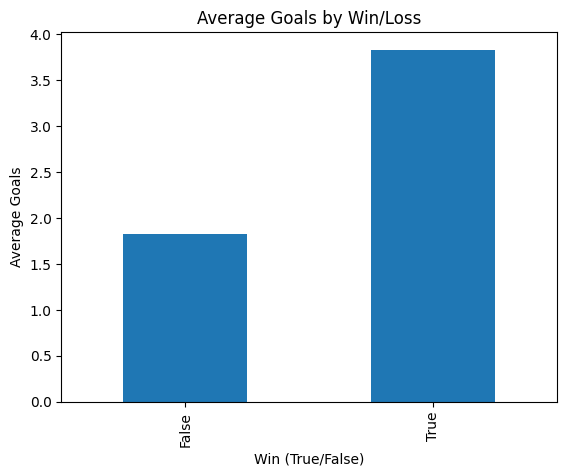

In [19]:
df.groupby('home_won')['home_goals'].mean().plot(kind='bar')
plt.title('Average Goals by Win/Loss')
plt.xlabel('Win (True/False)')
plt.ylabel('Average Goals')
plt.show()

## Section 8: New Feature Engineering

Shot efficiency measures how effectively teams convert shots into goals. We also standardize goals (z-score) as a “something new” technique.


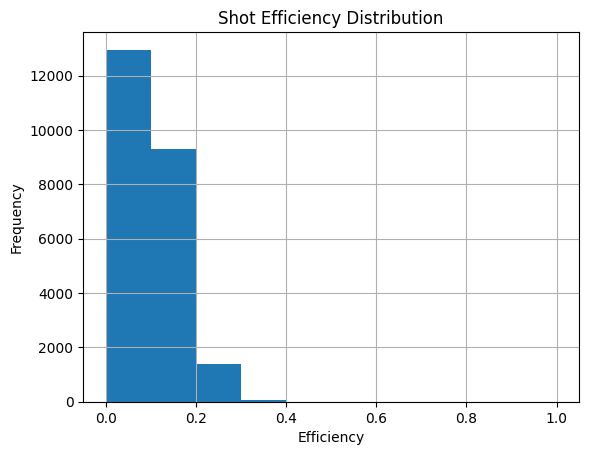

In [20]:
# New features
df['shot_efficiency'] = df['home_goals'] / df['home_shots']

# Standardization (something new)
df['goals_zscore'] = (df['home_goals'] - df['home_goals'].mean()) / df['home_goals'].std()

# Visualize new feature
plot_hist(df['shot_efficiency'], 'Shot Efficiency Distribution', 'Efficiency')

## Section 9: Trends Over Time

Line chart shows how average goals evolve over time.


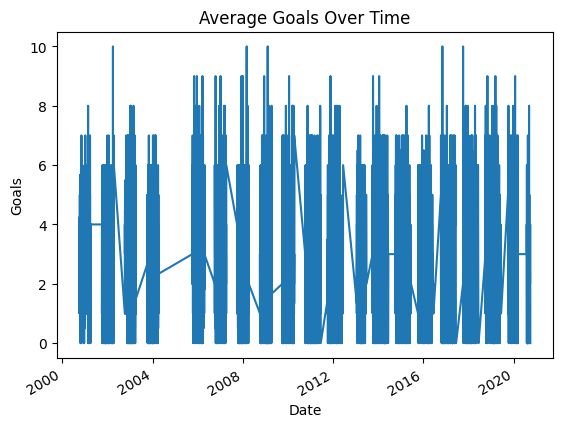

In [21]:
df.groupby('date_time_GMT')['home_goals'].mean().plot()
plt.title('Average Goals Over Time')
plt.xlabel('Date')
plt.ylabel('Goals')
plt.show()

## Section 10: Relationships Between Variables

Correlation and scatter plots assess relationships such as shots vs goals.


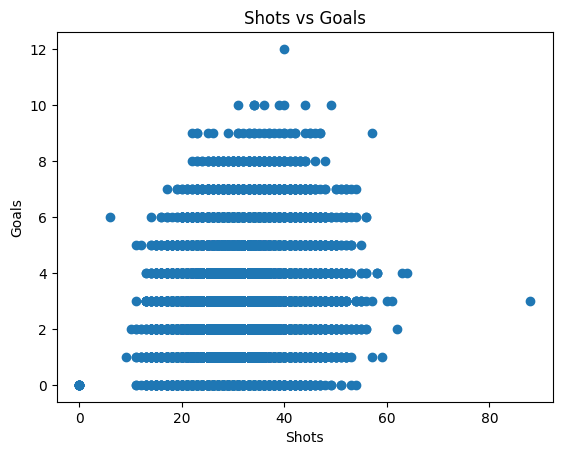

In [22]:
# Correlation
df[['home_goals','home_shots']].corr()

# Scatter
plt.scatter(df['home_shots'], df['home_goals'])
plt.title('Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.show()

## Section 11: Hypothesis

Teams that take more shots will generally score more goals. Home teams may also have a slight advantage due to familiarity and crowd support.


## Section 12: Linear Regression

We model goals as a function of shots.


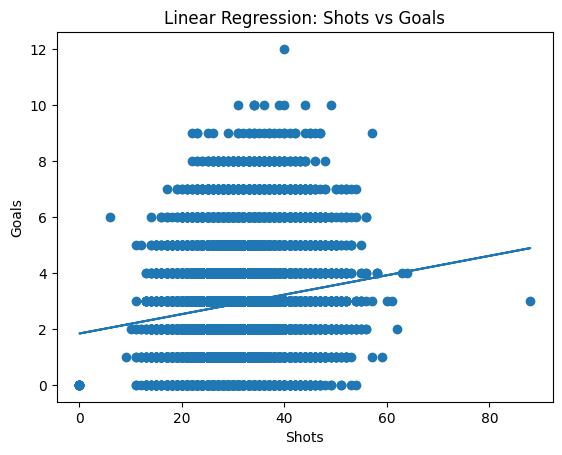

Coefficient: [0.03467205]
Intercept: 1.8359868762690623


In [23]:
# Clean for regression
df_clean = df[['home_shots','home_goals']].dropna()

X = df_clean[['home_shots']]
y = df_clean['home_goals']

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict(X)

# Plot
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title('Linear Regression: Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.show()

print('Coefficient:', model.coef_)
print('Intercept:', model.intercept_)

### Regression Discussion

The model shows a positive relationship between shots and goals. However, variation in the data indicates other factors (defense, shot quality, power plays) also influence outcomes. Because only one predictor is used, the model is limited; adding more variables would improve accuracy.


## Section 13: Conclusion

Overall, there is a clear relationship between shots and goals, supporting the hypothesis that offensive pressure leads to scoring. Home teams show a slight advantage, but outcomes depend on multiple factors.

The regression confirms shots as a useful predictor, though limited by using a single variable. Future work could include additional variables such as power play goals, faceoff win percentage, giveaways, takeaways, and blocked shots to better explain team performance and scoring outcomes.These variables also capture defensive aspects of the game, which are not included in the current model but play an important role in determining outcomes.
